# Dummy Latency Comparison

Compares synthetic latency for Razor's Edge objective strategies (`DEFAULT` = `MINMAX`, `FIFO`, `BATCH_SIZE`) and builds the
**Synthetic Latency Comparison with Different Strategies** table used in `PAPER.md`.


In [1]:
from pathlib import Path
import sys
import psutil
import os

repo_root = Path.cwd()

while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(repo_root / "src"))

p = psutil.Process(os.getpid())
if psutil.WINDOWS:
    p.nice(psutil.HIGH_PRIORITY_CLASS)
else:
    try:
        p.nice(-10)
    except psutil.AccessDenied:
        print("Elevation (sudo) is required to set high priority on Unix.")

In [2]:
import asyncio
import time
import random
import matplotlib.pyplot as plt
from collections import defaultdict

from batching_executor.process_manager import ComputeExecutor
from demos.synthetic.razors_edge_dummy_task_alt_latency import (
    RazorsEdgeDummyTaskDefault,
    RazorsEdgeDummyTaskFIFO,
    RazorsEdgeDummyTaskBatchSize,
)

strategy_tasks = [
    ("FIFO", RazorsEdgeDummyTaskFIFO),
    ("MINMAX", RazorsEdgeDummyTaskDefault),
    ("BATCH_SIZE", RazorsEdgeDummyTaskBatchSize),
]


## Start executor

In [3]:
executor = ComputeExecutor(
    [task for _, task in strategy_tasks],
    async_limit=16,
    model_thread_limit=1,
)
time.sleep(5)


## Basic functionality check

In [4]:
for strategy_name, task in strategy_tasks:
    sample = executor.sync_compute_fn(task, "hello razors edge")
    assert isinstance(sample, list)
    assert len(sample) > 0
    assert isinstance(sample[0], float)
    print(f"sync check passed for {strategy_name}")


sync check passed for FIFO
sync check passed for MINMAX
sync check passed for BATCH_SIZE


## Benchmark helpers

In [5]:
import string

from anyio import Semaphore


def generate_random_strings(n, a, b, seed=42):
    random.seed(seed)
    chars = string.ascii_letters + string.digits
    result = []
    for _ in range(n):
        length = random.randint(a, b)
        rand_str = ''.join(random.choice(chars) for _ in range(length))
        result.append(rand_str)
    return result


async def benchmark_async(target, max_token_count: int, request_count: int, seed: int) -> tuple[float, float, float, float, float]:
    payloads = generate_random_strings(request_count, 1, max_token_count, seed=seed)
    semaphore = Semaphore(17)
    start = time.perf_counter()
    all_times = []
    async def request(payload):
        async with semaphore:
            start_req = time.perf_counter()
            result = await executor.async_compute_fn(target, payload)
        all_times.append(time.perf_counter() - start_req)
        return result

    await asyncio.gather(*(request(payload) for payload in payloads))
    elapsed = time.perf_counter() - start

    all_times.sort()
    p95_idx = min(int(request_count * 0.95), request_count - 1)
    p99_idx = min(int(request_count * 0.99), request_count - 1)

    return (
        request_count / elapsed,
        sum(all_times) / request_count,
        all_times[p95_idx],
        all_times[p99_idx],
        max(all_times),
    )


## Run timing benchmarks and aggregate by strategy


In [6]:
max_token_size = 1000
n_req = 200
n_rounds = 5

raw_data = []
for round_idx in range(n_rounds):
    run_order = list(strategy_tasks)
    random.shuffle(run_order)
    for strategy_name, task in run_order:
        await benchmark_async(
            task,
            max_token_size,
            10,
            seed=42 + round_idx,
        )
        rps, avg, p95, p99, max_latency = await benchmark_async(
            task,
            max_token_size,
            n_req,
            seed=42 + round_idx,
        )
        raw_data.append((strategy_name, rps, avg, p95, p99, max_latency))
        print(
            f"round={round_idx + 1} strategy={strategy_name}",
            *(round(i, 4) for i in (rps, avg, p95, p99, max_latency)),
        )
        time.sleep(1)


round=1 strategy=FIFO 12.8253 1.2639 2.2037 2.668 2.7386
round=1 strategy=BATCH_SIZE 12.8986 1.2478 2.753 3.6275 3.6637
round=1 strategy=MINMAX 12.7938 1.2699 2.155 2.5296 2.5995
round=2 strategy=FIFO 12.8575 1.2616 2.0738 2.8466 2.8969
round=2 strategy=BATCH_SIZE 12.9465 1.2708 2.819 3.4166 3.5176
round=2 strategy=MINMAX 12.8137 1.2747 2.0326 2.6015 2.6715
round=3 strategy=FIFO 12.8148 1.2809 2.1167 2.2441 2.5561
round=3 strategy=BATCH_SIZE 12.7911 1.2893 2.8331 3.2707 3.579
round=3 strategy=MINMAX 12.8095 1.2876 1.9773 2.1981 2.4092
round=4 strategy=MINMAX 12.0988 1.3486 2.2537 2.828 3.2031
round=4 strategy=BATCH_SIZE 12.1392 1.3442 2.5315 3.6901 4.2542
round=4 strategy=FIFO 12.1033 1.3379 2.2932 2.7376 2.8178
round=5 strategy=BATCH_SIZE 13.0591 1.2594 2.5641 3.2116 3.287
round=5 strategy=FIFO 12.9541 1.2678 1.9769 2.1101 2.1214
round=5 strategy=MINMAX 12.9945 1.2688 1.9266 2.1258 2.1972


## Latency Comparison with Different Strategies

The table below mirrors the `PAPER.md` subsection title and reports:
- throughput (RPS)
- mean latency
- p95 latency
- p99 latency
- max latency

Strategy labels use DEFAULT/FIFO/BATCH_SIZE naming.


| Strategy | RPS | Mean Latency | P95 Latency | P99 Latency | Max Latency |
| --- | --- | --- | --- | --- | --- |
| FIFO | 12.710969 | 1.282433 | 2.132870 | 2.521277 | 2.626158 |
| MINMAX | 12.702064 | 1.289926 | 2.069032 | 2.456606 | 2.616079 |
| BATCH_SIZE | 12.766899 | 1.282302 | 2.700126 | 3.443307 | 3.660290 |


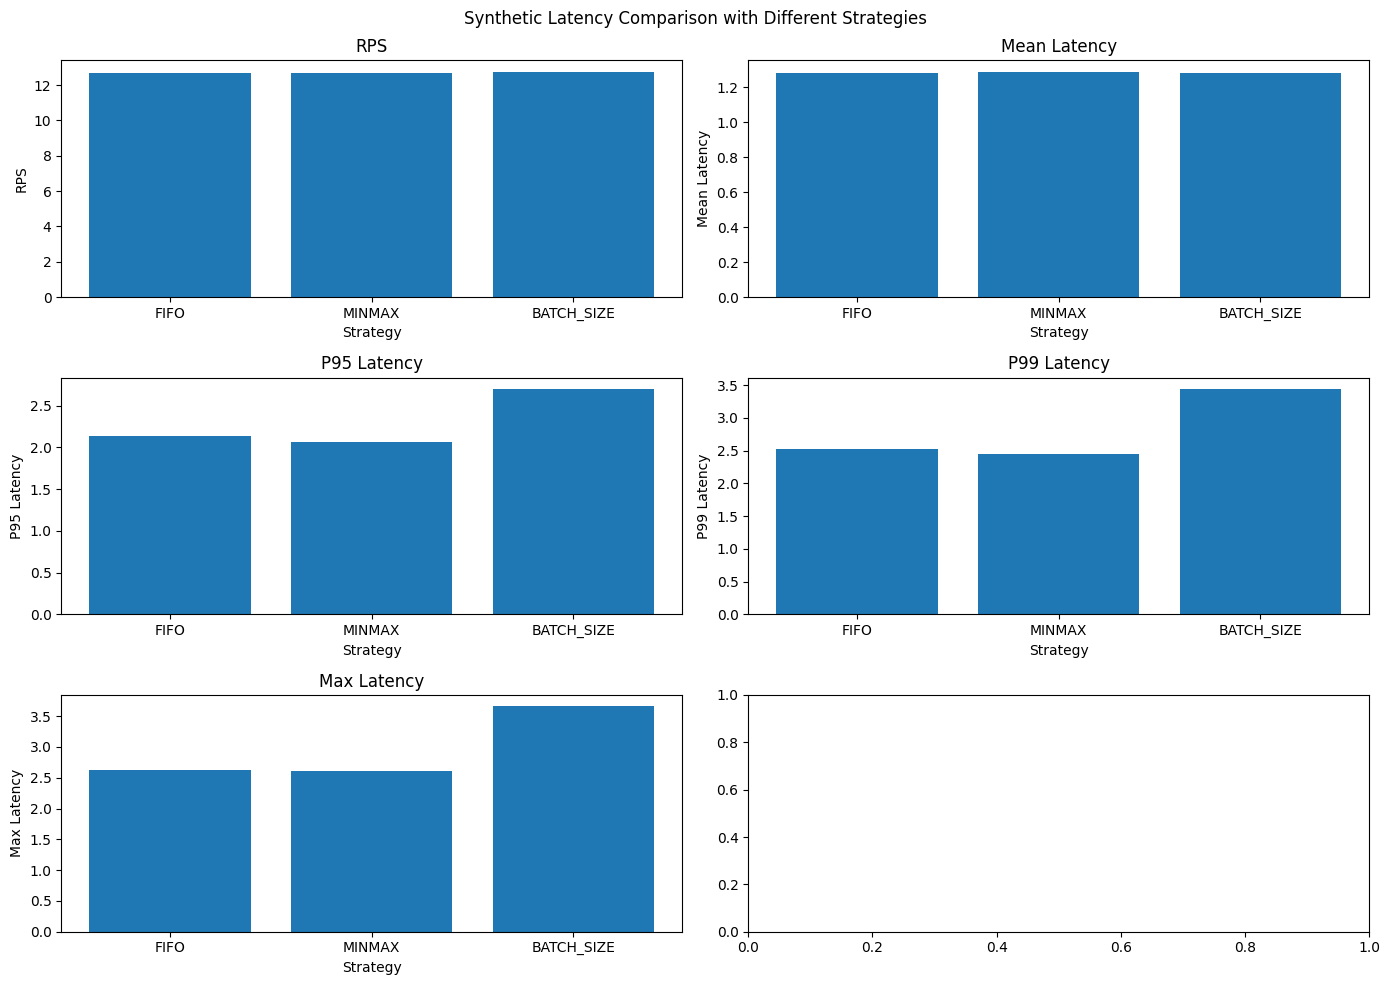

In [7]:
metrics_by_strategy = defaultdict(lambda: defaultdict(list))

for strategy_name, rps, avg, p95, p99, max_latency in raw_data:
    metrics_by_strategy[strategy_name]["RPS"].append(rps)
    metrics_by_strategy[strategy_name]["Mean Latency"].append(avg)
    metrics_by_strategy[strategy_name]["P95 Latency"].append(p95)
    metrics_by_strategy[strategy_name]["P99 Latency"].append(p99)
    metrics_by_strategy[strategy_name]["Max Latency"].append(max_latency)

strategy_order = [name for name, _ in strategy_tasks]
metric_order = ["RPS", "Mean Latency", "P95 Latency", "P99 Latency", "Max Latency"]

table_rows = []
for strategy_name in strategy_order:
    row = {"Strategy": strategy_name}
    for metric in metric_order:
        values = metrics_by_strategy[strategy_name][metric]
        row[metric] = sum(values) / len(values)
    table_rows.append(row)

header = ["Strategy"] + metric_order
divider = ["---"] * len(header)
lines = [
    "| " + " | ".join(header) + " |",
    "| " + " | ".join(divider) + " |",
]
for row in table_rows:
    lines.append(
        "| " + " | ".join(
            [row["Strategy"]] + [f"{row[m]:.6f}" for m in metric_order]
        ) + " |"
    )

latency_table_markdown = "\n".join(lines)
print(latency_table_markdown)

labels = [row["Strategy"] for row in table_rows]
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metric_order):
    values = [row[metric] for row in table_rows]
    ax.bar(labels, values)
    ax.set_title(metric)
    ax.set_xlabel("Strategy")
    ax.set_ylabel(metric)

fig.suptitle("Synthetic Latency Comparison with Different Strategies")
plt.tight_layout()
fig.savefig(Path("..") / ".." / "images" / f"{fig.get_suptitle()}.png")
plt.show()


In [8]:
print(latency_table_markdown)


| Strategy | RPS | Mean Latency | P95 Latency | P99 Latency | Max Latency |
| --- | --- | --- | --- | --- | --- |
| FIFO | 12.710969 | 1.282433 | 2.132870 | 2.521277 | 2.626158 |
| MINMAX | 12.702064 | 1.289926 | 2.069032 | 2.456606 | 2.616079 |
| BATCH_SIZE | 12.766899 | 1.282302 | 2.700126 | 3.443307 | 3.660290 |
